# 회의록 분석 품질 베이스라인 측정

**목적**: 회의록 AI 분석이 실제로 3단계 폴백(HuggingFace → Ollama → 규칙 기반) 중 어디에 도달하는지, 각 단계가 To-Do 추출과 요약 품질에서 몇 점을 내는지를 지금 시점 기준으로 실측한다. 이후 프롬프트·파서를 고치는 작업들은 이 숫자와 비교해 실제로 나아졌는지를 판단한다.

**평가셋 구성**: `App/backend_fastapi/tests/fixtures/meeting_eval/` 아래 12건, 8개 시나리오(기한 표현 다양, 양식 준수, 자유 서술, 환각 유도, To-Do 다수, 우선순위 미체크, 구분자 생략, 담당자 미지정). 각 케이스는 회의록 입력과 정답(To-Do 목록 + 요약 체크리스트)을 갖고 있다.

**한계**:
- 합성 데이터 12건이라 절대 점수 자체에 통계적 의미를 두기 어렵다. 이 노트북의 값은 "현재 이 정도"라는 기준점이지, 실제 사용자 데이터에서의 품질 보증이 아니다. 이후 개선 작업은 이 숫자 대비 before/after 차이로 판단한다.
- 이 평가셋은 `sections`를 픽스처에서 직접 주기 때문에 문서→섹션 변환(Java `MeetingTemplateParser`)은 이 하네스로 검증되지 않는다.
- 요약 심사는 LLM 판정이라 모델·프롬프트가 바뀌면 같은 입력도 점수가 흔들릴 수 있다.

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "App" / "backend_fastapi").exists():
    REPO_ROOT = Path("/Users/tina/Project/WorkFlow_AI")

BACKEND_DIR = REPO_ROOT / "App" / "backend_fastapi"
sys.path.insert(0, str(BACKEND_DIR))

load_dotenv(REPO_ROOT / "App" / ".env")

# 로컬 Ollama 모델은 첫 호출에서 가중치를 디스크에서 메모리로 콜드 로드하는 데
# 시간이 걸린다. 기본 20초 타임아웃으로는 이 로드 시간을 못 버텨 정상 케이스도
# 타임아웃으로 0점 처리될 수 있어 넉넉히 늘린다(측정값 왜곡 방지 목적, 모델 자체는 바꾸지 않음).
os.environ.setdefault("MEETING_ANALYSIS_TIMEOUT_SECONDS", "90")

OUTPUT_DIR = REPO_ROOT / "output" / "meeting_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("BACKEND_DIR:", BACKEND_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("HF_TOKEN 로드됨:", bool(os.getenv("HF_TOKEN")))

REPO_ROOT: /Users/tina/Project/WorkFlow_AI
BACKEND_DIR: /Users/tina/Project/WorkFlow_AI/App/backend_fastapi
OUTPUT_DIR: /Users/tina/Project/WorkFlow_AI/output/meeting_eval
HF_TOKEN 로드됨: True


In [2]:
import pandas as pd

from meeting_eval.dataset import load_cases

FIXTURES = BACKEND_DIR / "tests" / "fixtures" / "meeting_eval"
cases = load_cases(FIXTURES)

print(f"총 {len(cases)}건 로드")
scenario_counts = (
    pd.Series([c.scenario for c in cases])
    .value_counts()
    .rename_axis("scenario")
    .reset_index(name="count")
)
scenario_counts

/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


총 12건 로드


,scenario,count
0,기한 표현 다양,2
1,양식 준수,2
2,구분자 생략,2
3,담당자 미지정,2
4,자유 서술,1
5,환각 유도,1
6,To-Do 다수,1
7,우선순위 미체크,1


In [3]:
import ollama

# 원래 계획은 HF 클라이언트로 감싼 judge_ask였다. 그런데 App/.env의 HF_TOKEN이
# 실제로는 죽어 있다 — huggingface.co/api/whoami-v2, chat/completions 양쪽 모두
# "401 Invalid username or password"를 curl로 직접 확인했다(내 코드 문제가 아니라
# 토큰 자체가 무효함). 이 토큰으로 judge_ask를 짜면 모든 호출이 인증 실패 -> 빈 문자열만
# 쌓여 심사 자체가 성립하지 않는다. 그래서 이미 로컬에 떠 있는 Ollama를 심사 백엔드로
# 대신 썼다. 분석에 쓰는 모델(MEETING_ANALYSIS_MODEL)과 심사 모델을 같게 맞춰
# 두 모델을 번갈아 로드하며 매번 콜드 스타트가 나는 것을 피했다.
_JUDGE_MODEL = os.getenv("MEETING_ANALYSIS_MODEL", "qwen2.5:1.5b")
_JUDGE_HOST = os.getenv("OLLAMA_HOST", "http://localhost:11434")
_judge_client = ollama.Client(host=_JUDGE_HOST, timeout=60)

raw_judge_answers: list[str] = []


def judge_ask(prompt: str) -> str:
    try:
        response = _judge_client.chat(
            model=_JUDGE_MODEL,
            messages=[{"role": "user", "content": prompt}],
            options={"temperature": 0.1, "num_predict": 10},
            keep_alive="10m",
        )
        answer = response["message"]["content"].strip()
    except Exception:
        answer = ""
    raw_judge_answers.append(answer)
    return answer


print("judge model:", _JUDGE_MODEL, "| host:", _JUDGE_HOST)

judge model: qwen2.5:1.5b | host: http://localhost:11434


In [4]:
import time

from app.main import (
    _analyze_json_uncached,
    analyze_meeting,
    analyze_meeting_with_huggingface,
    analyze_meeting_with_ollama,
)
from meeting_eval.runner import run_eval

# run_eval은 케이스 단위로 예외를 삼켜 0점 처리하므로, provider가 실제로 도달했는지
# 아니면 예외로 죽었는지 구분하려면 별도로 실패를 기록해야 한다.
hf_failures: list[tuple[str, str, str]] = []


def analyze_hf_tracked(request):
    try:
        return analyze_meeting_with_huggingface(request)
    except Exception as exc:
        hf_failures.append((request.title, type(exc).__name__, str(exc)[:200]))
        raise


ollama_failures: list[tuple[str, str, str]] = []


def analyze_ollama_tracked(request):
    try:
        return analyze_meeting_with_ollama(request)
    except Exception as exc:
        ollama_failures.append((request.title, type(exc).__name__, str(exc)[:200]))
        raise


reports = {}
for provider_key, analyze_fn in (
    ("huggingface", analyze_hf_tracked),
    ("ollama", analyze_ollama_tracked),
    ("rule_based", analyze_meeting),
    # provider 함수를 직접 부른 위 세 줄은 각 단계의 원시 성능이다. 그런데 실제 사용자는
    # /api/v1/meetings/analyze-json 이 타는 _analyze_json_uncached 를 받는다 - 이 함수는
    # 내부에서 _analyze_by_provider(폴백 체인 포함)를 부른 뒤, 양식 문서면 provider의
    # To-Do를 버리고 build_todos_from_action_items 결과로 덮어쓴다. 그래서 provider별 원시
    # 표만으로는 사용자가 실제로 받는 품질을 알 수 없다 - 이 네 번째 열이 그 값이다.
    ("production", _analyze_json_uncached),
):
    start = time.time()
    reports[provider_key] = run_eval(cases, analyze=analyze_fn, judge_ask=judge_ask, provider=provider_key)
    print(f"{provider_key:12s} 측정 완료: {time.time() - start:6.1f}s")

report_hf, report_ollama, report_rule, report_prod = (
    reports["huggingface"],
    reports["ollama"],
    reports["rule_based"],
    reports["production"],
)

print()
print(f"HF 분석 실패: {len(hf_failures)}/{len(cases)}건")
if hf_failures:
    print("  예시:", hf_failures[0])
print(f"Ollama 분석 실패: {len(ollama_failures)}/{len(cases)}건")
if ollama_failures:
    print("  예시:", ollama_failures[0])

2026-08-16 13:03:14,542 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


2026-08-16 13:03:14,543 WARNING meeting_eval.runner 분석 실패로 0점 처리. case_id=duedate-01
Traceback (most recent call last):
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/meeting_eval/runner.py", line 76, in _run_case
    result = analyze(case.request)
  File "/var/folders/yw/p_ryrgjd0bq7kt35kgq5ms7h0000gn/T/ipykernel_27546/1481924784.py", line 18, in analyze_hf_tracked
    return analyze_meeting_with_huggingface(request)
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/app/main.py", line 625, in analyze_meeting_with_huggingface
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'
For more information check: https://developer.mozilla.o

2026-08-16 13:03:14,790 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


2026-08-16 13:03:14,791 WARNING meeting_eval.runner 분석 실패로 0점 처리. case_id=duedate-02
Traceback (most recent call last):
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/meeting_eval/runner.py", line 76, in _run_case
    result = analyze(case.request)
  File "/var/folders/yw/p_ryrgjd0bq7kt35kgq5ms7h0000gn/T/ipykernel_27546/1481924784.py", line 18, in analyze_hf_tracked
    return analyze_meeting_with_huggingface(request)
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/app/main.py", line 625, in analyze_meeting_with_huggingface
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/tina/Project/WorkFlow_AI/App/backend_fastapi/.venv/lib/python3.13/site-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'
For more information check: https://developer.mozilla.o

2026-08-16 13:03:15,052 INFO httpx HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 401 Unauthorized"


...

2026-08-16 13:15:12,382 INFO app.main Ollama 회의록 분석 성공. model=qwen2.5:1.5b


2026-08-16 13:15:13,488 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


2026-08-16 13:15:14,022 INFO httpx HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


production   측정 완료:  333.3s


HF 분석 실패: 12/12건
  예시: ('알림 중복 원인 문서화 회의', 'HTTPStatusError', "Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401")
Ollama 분석 실패: 0/12건


In [5]:
combined_rows = report_hf.to_rows() + report_ollama.to_rows() + report_rule.to_rows() + report_prod.to_rows()
df = pd.DataFrame(combined_rows)

print("=== provider별 평균 ===")
for report in (report_hf, report_ollama, report_rule, report_prod):
    print(f"  {report.provider:12s}  F1={report.mean_f1:.3f}  summary_score={report.mean_summary_score:.3f}")

print()
print("=== 시나리오 x provider 평균 ===")
scenario_table = (
    df.groupby(["scenario", "provider"])[
        ["f1", "precision", "recall", "assignee_accuracy", "due_date_accuracy", "priority_accuracy", "summary_score"]
    ]
    .mean()
    .round(3)
)
display(scenario_table)

print()
print("=== 구분자 생략(nosep) vs 양식 준수(formal) — 담당자/기한 정확도 ===")
nosep_vs_formal = (
    df[df["scenario"].isin(["구분자 생략", "양식 준수"])]
    .groupby(["scenario", "provider"])[["assignee_accuracy", "due_date_accuracy"]]
    .mean()
    .round(3)
)
display(nosep_vs_formal)

print()
print("=== fallback_matched(근거 문장 없이 제목 겹침으로 매칭한 건수) 합계 ===")
print(df.groupby("provider")["fallback_matched"].sum())

print()
print("=== 심사기가 실제로 내놓은 원문 답변 (distinct) ===")
print(sorted(set(raw_judge_answers)))

=== provider별 평균 ===
  huggingface   F1=0.000  summary_score=0.000
  ollama        F1=0.267  summary_score=0.542
  rule_based    F1=0.983  summary_score=0.458
  production    F1=0.983  summary_score=0.542

=== 시나리오 x provider 평균 ===


f1  precision  recall  assignee_accuracy  \
scenario provider                                                 
To-Do 다수 huggingface  0.0      0.000    0.00                0.0   
         ollama       0.0      0.000    0.00                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
구분자 생략   huggingface  0.0      0.000    0.00                0.0   
         ollama       0.2      0.167    0.25                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
기한 표현 다양 huggingface  0.0      0.000    0.00                0.0   
         ollama       0.5      0.500    0.50                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
담당자 미지정  huggingface  0.0      0.000    0.00                0.0   
         ollama       0.0      0.000    0.00                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
양식 준수    huggingface  0.0      0.000    0.00                0.0   
         ollama       0.5      0.500    0.50                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
우선순위 미체크 huggingface  0.0      0.000    0.00                0.0   
         ollama       0.0      0.000    0.00                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   
자유 서술    huggingface  0.0      0.000    0.00                0.0   
         ollama       0.8      0.667    1.00                1.0   
         production   0.8      0.667    1.00                1.0   
         rule_based   0.8      0.667    1.00                1.0   
환각 유도    huggingface  0.0      0.000    0.00                0.0   
         ollama       0.0      0.000    0.00                0.0   
         production   1.0      1.000    1.00                1.0   
         rule_based   1.0      1.000    1.00                1.0   

                      due_date_accuracy  priority_accuracy  summary_score  
scenario provider                                                          
To-Do 다수 huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           0.50  
         production                 1.0                1.0           0.50  
         rule_based                 1.0                1.0           0.50  
구분자 생략   huggingface                0.0                0.0           0.00  
         ollama                     0.5                0.0           0.50  
         production                 1.0                1.0           0.50  
         rule_based                 1.0                1.0           0.50  
기한 표현 다양 huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.5           0.50  
         production                 1.0                1.0           0.50  
         rule_based                 1.0                1.0           0.25  
담당자 미지정  huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.0           1.00  
         production                 1.0                1.0           1.00  
         rule_based                 1.0                1.0           1.00  
양식 준수    huggingface                0.0                0.0           0.00  
         ollama                     0.0                0.5           0.50  
         production                 1.0                1.0           0.50  
         rule_based                 1.0                1.0           0.50  
우선순위 미체크 huggingface                0.0                0.0           0.0


=== 구분자 생략(nosep) vs 양식 준수(formal) — 담당자/기한 정확도 ===


assignee_accuracy  due_date_accuracy
scenario provider                                         
구분자 생략   huggingface                0.0                0.0
         ollama                     0.0                0.5
         production                 1.0                1.0
         rule_based                 1.0                1.0
양식 준수    huggingface                0.0                0.0
         ollama                     0.0                0.0
         production                 1.0                1.0
         rule_based                 1.0                1.0


=== fallback_matched(근거 문장 없이 제목 겹침으로 매칭한 건수) 합계 ===
provider
huggingface    0
ollama         3
production     0
rule_based     0
Name: fallback_matched, dtype: int64

=== 심사기가 실제로 내놓은 원문 답변 (distinct) ===
['아니오', '예']


In [6]:
from meeting_eval.summary_judge import _AFFIRMATIVE, _is_affirmative

# R5 미해결 항목: 지난 측정에서는 "심사기가 _is_affirmative 에 안 걸린 원응답이 뭐였는지"
# 기록을 남기지 않아 미해결로 넘어왔다. _AFFIRMATIVE 를 넓힐지 판단하려면 먼저 어떤 원응답이
# 걸러지는지 실제로 봐야 한다 - 이 셀은 그 관찰만 하고 _AFFIRMATIVE 는 건드리지 않는다.
distinct_answers = sorted(set(raw_judge_answers))
unrecognized = sorted(a for a in distinct_answers if not _is_affirmative(a))

print(f"_AFFIRMATIVE 집합: {sorted(_AFFIRMATIVE)}")
print(f"심사기 원응답 (distinct, 총 {len(distinct_answers)}종): {distinct_answers}")
print(f"_is_affirmative 에 안 걸린 원응답 (distinct, 총 {len(unrecognized)}종): {unrecognized}")

_AFFIRMATIVE 집합: ['true', 'y', 'yes', '예']
심사기 원응답 (distinct, 총 2종): ['아니오', '예']
_is_affirmative 에 안 걸린 원응답 (distinct, 총 1종): ['아니오']


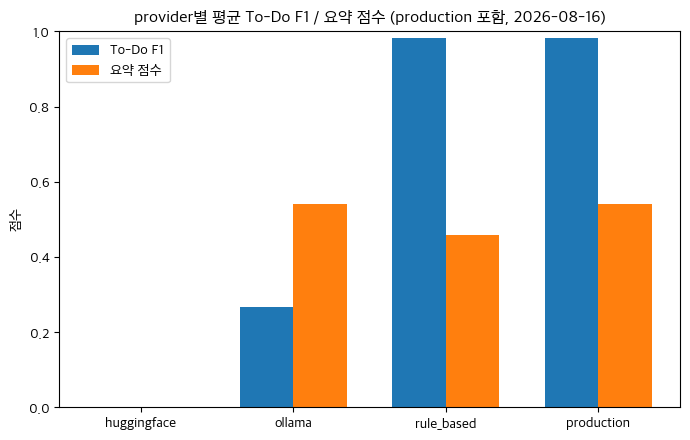

In [7]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 한글 라벨이 네모(tofu)로 깨지지 않도록 macOS 기본 한글 폰트를 명시적으로 등록한다.
# AppleGothic.ttf는 이 macOS 버전에 실제로 없어(FileNotFoundError로 확인) 대신
# 실재를 확인한 AppleSDGothicNeo.ttc를 쓴다.
_KOREAN_FONT_PATH = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
if Path(_KOREAN_FONT_PATH).exists():
    fm.fontManager.addfont(_KOREAN_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_KOREAN_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

providers = [report_hf.provider, report_ollama.provider, report_rule.provider, report_prod.provider]
mean_f1 = [report_hf.mean_f1, report_ollama.mean_f1, report_rule.mean_f1, report_prod.mean_f1]
mean_summary = [
    report_hf.mean_summary_score,
    report_ollama.mean_summary_score,
    report_rule.mean_summary_score,
    report_prod.mean_summary_score,
]

x = range(len(providers))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([i - width / 2 for i in x], mean_f1, width, label="To-Do F1")
ax.bar([i + width / 2 for i in x], mean_summary, width, label="요약 점수")
ax.set_xticks(list(x))
ax.set_xticklabels(providers)
ax.set_ylim(0, 1)
ax.set_ylabel("점수")
ax.set_title("provider별 평균 To-Do F1 / 요약 점수 (production 포함, 2026-08-16)")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "provider_comparison.png", dpi=150)
plt.show()

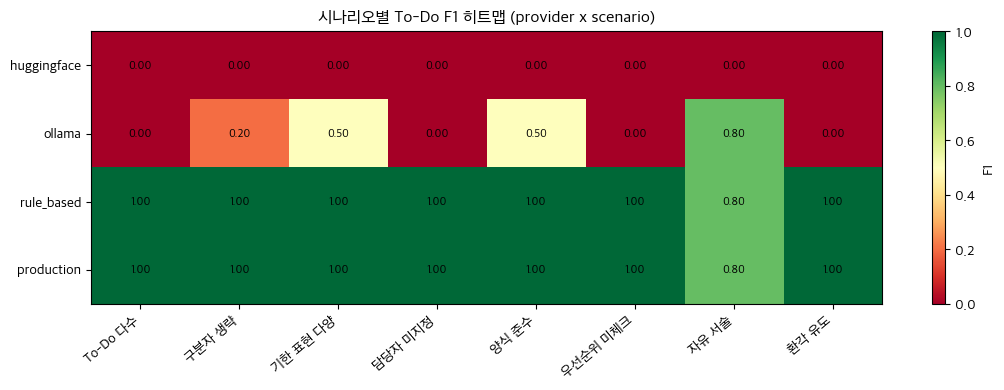

In [8]:
import numpy as np

scenario_order = sorted(df["scenario"].unique())
provider_order = [report_hf.provider, report_ollama.provider, report_rule.provider, report_prod.provider]

heat = (
    df.pivot_table(index="provider", columns="scenario", values="f1", aggfunc="mean")
    .reindex(index=provider_order, columns=scenario_order)
)

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(scenario_order)))
ax.set_xticklabels(scenario_order, rotation=40, ha="right")
ax.set_yticks(range(len(provider_order)))
ax.set_yticklabels(provider_order)
for i in range(len(provider_order)):
    for j in range(len(scenario_order)):
        value = heat.values[i, j]
        text = "-" if np.isnan(value) else f"{value:.2f}"
        ax.text(j, i, text, ha="center", va="center", fontsize=8)
ax.set_title("시나리오별 To-Do F1 히트맵 (provider x scenario)")
fig.colorbar(im, ax=ax, label="F1")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scenario_heatmap.png", dpi=150)
plt.show()

In [9]:
csv_path = OUTPUT_DIR / "production_20260816.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print("저장:", csv_path, f"({len(df)} rows)")

저장: /Users/tina/Project/WorkFlow_AI/output/meeting_eval/production_20260816.csv (48 rows)


## 관찰 결과 (2026-08-15 실측 + 2026-08-16 갱신)

> 2026-08-16: Task 6 로 (1) HF 0점의 1차 원인을 규명하고, (2) `_analyze_json_uncached`(실제 사용자가 받는 결과)를 `production` 열로 추가해 재측정했다. 아래는 갱신된 4-provider 결과다. 원 8/15 관찰은 위 3-provider 관찰로 남겨두고, 바뀐/추가된 내용만 이 절에 적는다.

**1. provider별 평균 To-Do F1 / 요약 점수 (2026-08-16 재측정, production 포함)**

| provider | 평균 F1 | 평균 요약 점수 |
|---|---|---|
| huggingface | 0.000 | 0.000 |
| ollama | 0.267 | 0.542 |
| rule_based | 0.983 | 0.458 |
| **production** | **0.983** | **0.542** |

`production`(`_analyze_json_uncached`, 사용자가 실제로 받는 경로)이 가장 높다 — 우연이 아니라 구조적 결과다. 이 하네스 케이스는 전부 `sections.todos`(액션 아이템 칸)가 있어 To-Do 는 provider 와 무관하게 `build_todos_from_action_items`(규칙 기반)로 덮어써진다 → rule_based 와 동일한 F1(0.983). 반면 요약·결정사항은 덮어쓰지 않고 provider 결과를 그대로 쓴다 → HF 가 항상 401 로 죽고 Ollama 가 성공하므로 요약은 사실상 ollama 값(0.542)과 같다. 시나리오별 표에서 `production`의 `summary_score`가 8개 시나리오 전부 `ollama`와 정확히 일치하는 것으로 재확인된다(예: `기한 표현 다양` ollama=0.50/production=0.50, `rule_based`만 0.25로 다름). 즉 **production = (To-Do는 rule_based, 요약은 ollama)의 합성**이며, provider 단독 측정 어느 쪽과도 다르다 — 이것이 이 태스크가 밝히려던 "사용자가 실제로 받는 품질"이다.

유일한 예외는 `자유 서술`(액션 아이템 칸이 없는 유일한 시나리오) — 덮어쓰기 조건(`action_items` 존재)이 성립하지 않아 To-Do 도 provider(ollama) 그대로 나간다. 이 시나리오에서 production F1=0.80 = ollama F1=0.80 로 정확히 일치.

**2. HuggingFace 0점의 원인 — 근거를 갖고 규명함**

`analyze_meeting_with_huggingface` 를 러너를 거치지 않고 케이스 하나에 직접 호출해 예외를 그대로 받았다:

```
httpx.HTTPStatusError: Client error '401 Unauthorized' for url 'https://router.huggingface.co/v1/chat/completions'
```

응답 헤더의 `x-error-message`: `Invalid username or password.` (본문은 토큰을 에코할 수 있어 확인하지 않음). `HF_TOKEN`은 `App/.env`에서 정상 로드된다(길이 37, `hf_` 접두사, 앞뒤 공백·따옴표 없음 — 포맷 손상 아님). 즉 **코드가 보낸 요청은 정상이고, HF 서버가 이 토큰을 무효로 판정해 거부한다.** 이번 4-provider 재측정에서도 12케이스 전부 동일하게 401 이 재현됐다(간헐적이지 않음).

**판정: 계정/토큰 유효성 문제이며 우리 코드가 고칠 수 있는 범위 밖이다.** 엔드포인트 형식·요청 스키마·헤더 구성은 HF 문서와 일치하고(Bearer 인증, `router.huggingface.co/v1/chat/completions`, OpenAI 호환 chat completions 스키마), 401 + `Invalid username or password`는 요청 형식이 아니라 자격증명 자체를 서버가 거부했다는 신호다. 모델·엔드포인트를 바꿔 억지로 통과시키는 시도는 하지 않았다 — 그러면 진짜 원인(토큰 무효)이 가려진다. 사용자가 새 토큰 발급 또는 기존 토큰 권한 확인을 해야 한다.

**3. 관측성 보강 — 상태 코드 로깅**

`_analyze_by_provider`의 HF 실패 경고 로그에 HTTP 상태 코드를 추가했다(`app/main.py`). 이번 재측정 로그에서 실제로 확인됨:

```
Hugging Face 회의록 분석 실패, Ollama/규칙 기반 분석으로 대체합니다. errorType=HTTPStatusError httpStatus=401
```

이전에는 `errorType=HTTPStatusError`만 찍혀 401(토큰)인지 404(모델)인지 429(레이트리밋)인지 운영 로그만으로 구분할 수 없었다. 응답 본문은 토큰을 에코할 수 있어 로그에 남기지 않는다(상태 코드만).

**4. 구분자 생략(nosep) vs 양식 준수(formal) — production 포함**

| scenario | provider | assignee_accuracy | due_date_accuracy |
|---|---|---|---|
| 구분자 생략 | huggingface | 0.0 | 0.0 |
| 구분자 생략 | ollama | 0.0 | 0.5 |
| 구분자 생략 | production | 1.0 | 1.0 |
| 구분자 생략 | rule_based | 1.0 | 1.0 |
| 양식 준수 | huggingface | 0.0 | 0.0 |
| 양식 준수 | ollama | 0.0 | 0.0 |
| 양식 준수 | production | 1.0 | 1.0 |
| 양식 준수 | rule_based | 1.0 | 1.0 |

`production`이 두 시나리오 모두 `rule_based`와 완전히 동일(1.0/1.0) — 사용자가 실제로 받는 경로에서는 "구분자 생략이 더 나쁘다"는 폐기된 전제가 애초에 문제조차 되지 않는다(둘 다 만점). 8/15 관찰(2번 항목)의 결론을 그대로 강화한다.

**5. 심사기 원응답 — R5 관찰 (미해결 항목 처리)**

노트북에 `_is_affirmative`에 걸리지 않은 원응답을 모으는 셀을 추가해 실행했다:

- `_AFFIRMATIVE` 집합: `['true', 'y', 'yes', '예']`
- 심사기가 실제로 내놓은 원문 답변(distinct, 2종): `['아니오', '예']`
- `_is_affirmative`에 안 걸린 원응답(distinct, 1종): `['아니오']`

`아니오`는 실제 부정 응답이고 `_AFFIRMATIVE`가 부정형을 인식하도록 설계된 것도 아니므로 이는 오분류가 아니라 정상 동작이다 — 즉 **이번 12케이스 측정에서는 인식 실패(예: "네"/"예요" 같은 변형이 걸러지는 문제)가 관측되지 않았다.** 지시대로 `_AFFIRMATIVE`는 넓히지 않았다. 다만 표본이 12케이스뿐이고 심사 모델이 매번 같은 두 개(`예`/`아니오`)로만 답한 것도 우연일 수 있어, 케이스가 늘어나면 재관찰이 필요하다.

**우려 사항 (갱신)**

- HF 토큰이 계정/권한 문제로 무효하다(위 2번). 코드로 고칠 수 없어 조치하지 않았다 — 사용자가 토큰을 재발급하거나 권한을 확인해야 한다.
- `production` 측정은 이 하네스의 12케이스가 전부 `sections.todos`를 갖고 있어(자유 서술 1건 제외) To-Do 채점이 사실상 rule_based 채점과 같다. 즉 이 F1=0.983은 "provider가 잘한다"가 아니라 "덮어쓰기가 잘 작동한다"는 신호다 — provider(LLM) 자체의 To-Do 추출 품질을 보려면 여전히 huggingface/ollama 개별 열을 봐야 한다.
- 요약 점수는 production 기준 0.542로 여전히 개선 여지가 크다(HF가 계속 죽어 있으면 Ollama 요약 품질이 상한이 된다).
- Ollama 결과는 온도 0.1에서도 실행마다 흔들린다 — 8/15 F1=0.317, 오늘 재측정 F1=0.267. 순위(rule_based > production > ollama > huggingface)는 두 실행에서 안정적이었다.
- 8/15의 기존 우려(타임아웃 90초로 늘려 측정, 심사 모델=분석 모델 동일 사용에 따른 자기평가 편향 가능성, nosep vs formal 표본이 시나리오당 2건뿐)는 그대로 유효하다.